## _Events from CSV_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### _Load Dataset_

In [6]:
# mu+mu- data (current)
input_dir = 'train_all'

In [7]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

print("Total Events: ", len(file_prefixes))

Total Events:  10000


In [8]:
# test to load an event
event_prefix = file_prefixes[5]

hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000005 memory usage 0.02 MB


In [9]:
# hits.head()

In [10]:
# tubes.head()

In [11]:
# particles.head()

In [12]:
# truth.head()

### _(A) - SttCSVReader Class_

In [13]:
from src import SttCSVReader
from src import Draw_Reader_Event

In [14]:
reader = SttCSVReader(path=input_dir, noise=True, skewed=True)

### _1. Read Event_

In [34]:
event_id = 1074

In [35]:
data = reader(event_id)

In [36]:
# data.event_file

In [37]:
# data.hits.head()

In [38]:
# data.tubes.head()

In [39]:
# data.particles.head()

In [40]:
# data.event.head()

In [41]:
data.event.layer.unique()

array([0], dtype=int32)

### _2. Event Display_

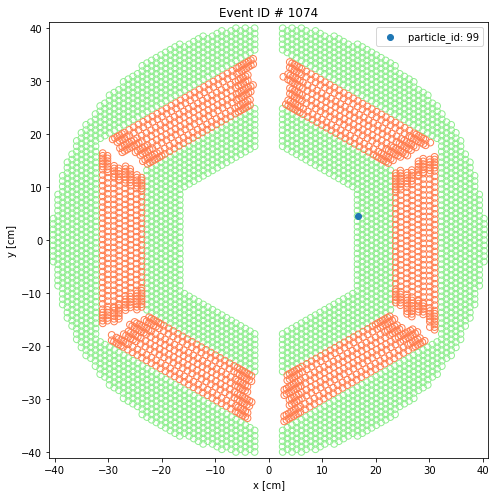

In [42]:
Draw_Reader_Event(reader(event_id),figsize=(7,7),save_fig=False);

### _3. Reconstructable Events_

In [ ]:
sum_tp, sum_rp = 0, 0

for i in range(10000):
    event = reader(i)
        
    truth_particles = event.particles.merge(event.truth, on='particle_id', how='left')
    sum_tp += np.unique(truth_particles.particle_id).size
    
    truth_particles = truth_particles[truth_particles.nhits > 4]                 # particles with nhits > 4
    reconstructable_particles = truth_particles[truth_particles.pt > 0.05]       # particles with pt > 50 MeV
    sum_rp += np.unique(reconstructable_particles.particle_id).size

In [ ]:
print(f"Total True Tracks: {sum_tp}, Total Reconstructable Tracks: {sum_rp}")
print("fraction of reconstructable particles (n > 4 and pt > 50MeV): {:.3f}".format((sum_rp/sum_tp)*100))

### _4. Number of Hits/Track_

In [ ]:
data = reader(8512)

In [ ]:
data.particles

In [ ]:
data.particles.hist(column='nhits')

### _5. Handling Noise Hits_

- from `LightningModule/Processing/utils/event_utils.py`

#### _1. Keep the Noise_

In [ ]:
truth_1 = truth
hits_1 = hits

In [ ]:
truth_1 = truth_1.merge(particles, on="particle_id", how="left") # how='left' keeps noise hits even if truth.particle_id is not matched with particles.particle_id

In [ ]:
truth_1.particle_id.unique()

In [ ]:
hits_1 = hits_1.merge(truth_1, on="hit_id")

In [ ]:
hits_1.particle_id.values

In [ ]:
# Here noise hits are assigned particle_id = 6, 46
hits_1.particle_id.unique()

#### _2. Remove the Noise_

In [ ]:
truth_2 = truth
hits_2 = hits

In [ ]:
truth_2 = truth_2.merge(particles, on="particle_id", how="inner") # how='inner' removes noise hits, matched the truth.particle_id with particles.particle_id

In [ ]:
truth_2.particle_id.unique()

In [ ]:
hits_2 = hits_2.merge(truth_2, on="hit_id", how="inner")

In [ ]:
hits_2.particle_id.values

In [ ]:
hits_2.particle_id.unique()

#### _3. Add/Remove Noise_

- from `src/event.py`

In [ ]:
# particles (signal) info
particles.particle_id.values

In [ ]:
# let see if noise hits are recorded
truth.particle_id.unique()

In [ ]:
h = hits.merge(truth, on='hit_id', how='left')

In [ ]:
h.particle_id.unique()

In [ ]:
h = h.merge(particles, on='particle_id', how='left')

In [ ]:
h.particle_id.unique()

In [ ]:
h.particle_id.values